In [1]:
%load_ext autoreload
%autoreload 2

In [49]:
import sys
sys.path.append('/tank/klundert/projects/cfdn/prfpy_cfdn/')
import os
import numpy as np
import preprocess
import cortex as cx
import numpy as np
import scipy as sp
import nilearn as nl
from nilearn.surface import load_surf_data
import os, shutil, urllib.request
import cortex as cx
from matplotlib import rc
import nibabel as nb
from nibabel import cifti2
import h5py
import matplotlib.pyplot as plt
from prfpy.stimulus import PRFStimulus2D
from prfpy.model import Iso2DGaussianModel, CSS_Iso2DGaussianModel
from prfpy.fit import Iso2DGaussianFitter, CSS_Iso2DGaussianFitter
from prfpy.utils import Subsurface
from prfpy.stimulus import CFStimulus
from prfpy.model import CFGaussianModel
from prfpy.fit import CFFitter
from prfpy.model import Norm_CFGaussianModel
from prfpy.fit import Norm_CFGaussianFitter
from scipy.optimize import LinearConstraint, NonlinearConstraint
from scipy.io import loadmat
from scipy.ndimage import median_filter, gaussian_filter, binary_propagation

In [50]:
from preprocess import get_cortex

In [51]:
import cfhcpy
from cfhcpy.base import AnalysisBase
from cfhcpy.base import AnalysisBase

In [52]:
ab = AnalysisBase()

In [53]:
ab.startup(subject='999999', experiment_id="ret", yaml_file="/tank/klundert/projects/hcp_movie/config.yml")

Starting analysis of subject 999999 on romulus with settings 
{
 "identifier": "node230",
 "base_dir": "/scratch/2019/visual/hcp_{experiment}/",
 "code_dir": "/tank/tkn219/projects/hcp_movie/",
 "threads": 40
}


In [54]:
data_train = ab._read_tc_data(run=0)

Getting whole-brain data from: /scratch/2019/visual/hcp_ret/subjects/999999/tfMRI_RETBAR1_*_Atlas_1.6mm_MSMAll_hp2000_clean.dtseries_sg_psc.nii


In [55]:
data_test = ab._read_tc_data(run=1)

Getting whole-brain data from: /scratch/2019/visual/hcp_ret/subjects/999999/tfMRI_RETBAR2_*_Atlas_1.6mm_MSMAll_hp2000_clean.dtseries_sg_psc.nii


In [56]:
get_cortex(data.T).shape

(118584, 300)

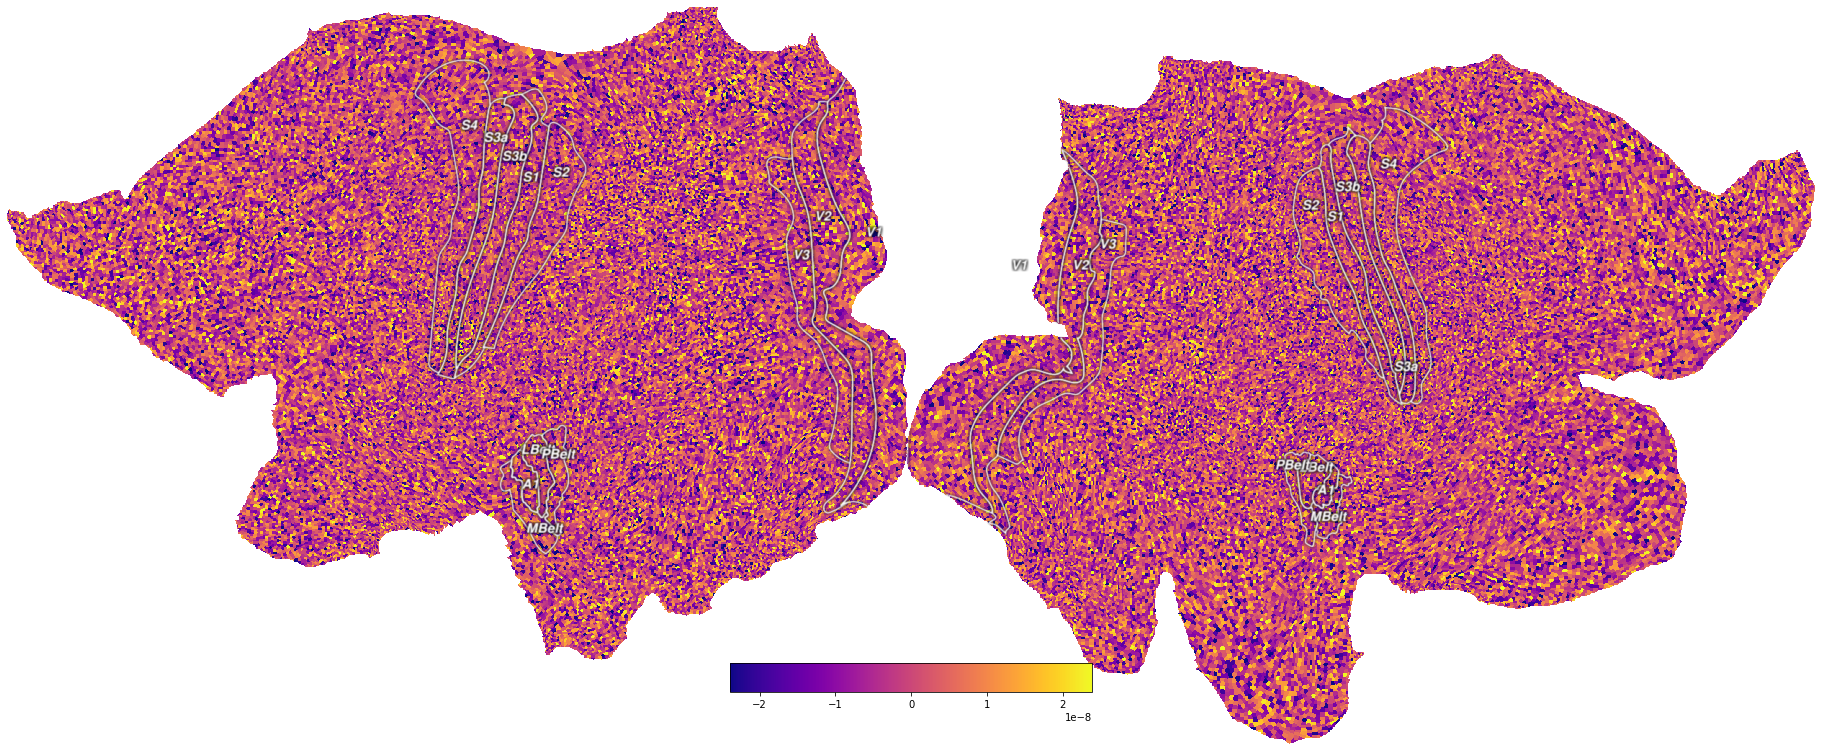

In [20]:
cx.quickshow(cx.Vertex(get_cortex(data.T).mean(axis=1), subject='hcp_999999', cmap='plasma'), with_curvature=True);


In [57]:
ab.prf_ecc_threshold
ab.prf_rsq_threshold

0.2

In [269]:
# data_train = get_cortex(data_train.T)
# data_test = get_cortex(data_test.T)
ab.atlas_roi_frames

{'V1L': 181,
 'V1R': 1,
 'V2L': 184,
 'V2R': 4,
 'V3L': 185,
 'V3R': 5,
 'V3AL': 193,
 'V3AR': 13,
 'V3BL': 199,
 'V3BR': 19,
 'V7L': 196,
 'V7R': 16,
 'IPS1L': 197,
 'IPS1R': 17,
 'LIPvL': 228,
 'LIPvR': 48,
 'LIPdL': 275,
 'LIPdR': 95,
 'VIPL': 229,
 'VIPR': 49,
 'MIPL': 230,
 'MIPR': 50,
 'FEFL': 190,
 'FEFR': 10,
 'MSTL': 182,
 'MSTR': 2,
 'MTL': 203,
 'MTR': 23,
 'LO1L': 200,
 'LO1R': 20,
 'LO2L': 201,
 'LO2R': 21,
 'LO3L': 339,
 'LO3R': 159,
 'A1L': 204,
 'A1R': 24,
 'PBeltL': 304,
 'PBeltR': 124,
 'MBeltL': 353,
 'MBeltR': 173,
 'LBeltL': 354,
 'LBeltR': 174,
 '52L': 283,
 '52R': 103,
 'RIL': 284,
 'RIR': 104,
 'CS1_4L': 188,
 'CS1_4R': 8,
 'CS2_3aL': 233,
 'CS2_3aR': 53,
 'CS3_3bL': 189,
 'CS3_3bR': 9,
 'CS4_1L': 231,
 'CS4_1R': 51,
 'CS5_2L': 232,
 'CS5_2R': 52,
 'PGiL': 330,
 'PGiR': 150,
 'PGsL': 331,
 'PGsR': 151,
 'PFmL': 329,
 'PFmR': 149,
 'v23abL': 213,
 'v23abR': 33,
 'd23abL': 214,
 'd23abR': 34,
 '7mL': 210,
 '7mR': 30,
 '31pvL': 215,
 '31pvR': 35,
 '31pdL': 341,
 '3

In [372]:
import h5py
idxs = h5py.File('/tank/shared/timeless/atlases/cifti_indices.hdf5', "r")
lidxs = np.array(idxs['Left_indices'])
ridxs = np.array(idxs['Right_indices'])
allidxs = np.concatenate([lidxs, ridxs])
def get_cortex(dat):
    l, r, = dat[lidxs], dat[ridxs]

    # Replace the minus 1
    l[lidxs == -1] = np.zeros_like(l[lidxs == -1])
    r[ridxs == -1] = np.zeros_like(r[ridxs == -1])

    # Last dimension time.
    # l, r = l.T, r.T

    data = np.concatenate([l, r])
    return data

def angle(x0, y0):
    return np.angle(x0 + y0 * 1j)

def ecc(x0, y0):
    return np.abs(x0 + y0 * 1j)

def splitList(array):
    n = len(array)
    half = int(n/2) # py3
    return array[:half], array[n-half:]



roi_index_dict = {
    # somatosensory:
    'CS1_4': 8, 'CS2_3a': 53, 'CS3_3b': 9, 'CS4_1': 51, 'CS5_2': 52,
    # auditory:
    'A1': 24, 'PBelt': 124, 'MBelt': 173, 'LBelt': 174, '52': 103, 'RI': 104,
    # low-level visual:
    'V1': 1, 'V2': 4, 'V3': 5,
    # mid-level and high-level visual:
    'V3A': 13, 'V3B': 19, 'IPS1': 17, 'LIPv': 48, 'LIPd': 95, 
    'VIP': 49, 'MST': 2, 'MT': 23, 'LO1': 20, 'LO2': 21, 'LO3': 159, 'MIP': 50
    }

atlas_data = np.concatenate([load_surf_data(
        os.path.join('/tank/klundert/content/data/atlas', f'Q1-Q6_RelatedParcellation210.CorticalAreas_dil_Colors.59k_fs_LR.dlabel.{hemi}.gii'))
         for hemi in ['L', 'R']])
atlas_data_both_hemis = np.mod(atlas_data, 180)


ind = np.array(list(roi_index_dict.values()))[12:]
boolmask_old = atlas_data_both_hemis == roi_index_dict['V2']
for i, ROIs in enumerate(ind):
    boolmask_old = np.array(atlas_data_both_hemis == ind[i]) + boolmask_old
    print(ROIs)

4
5
13
19
17
48
95
49
2
23
20
21
159
50


In [357]:
import pandas as pd
df = pd.read_csv('/tank/klundert/projects/cfdn/scripts/ROI.csv')

df['regionID'][df['Cortex_ID'] < 6][df['regionID'][df['Cortex_ID'] < 6]<181].values[1:]

array([  2,   3,   4,   5,   6,   7,  13,  16,  17,  18,  19,  20,  21,
        22,  23, 138, 152, 153, 154, 156, 157, 158, 159, 160, 163])

In [373]:


atlas_data = np.concatenate([load_surf_data(
        os.path.join('/tank/klundert/content/data/atlas', f'Q1-Q6_RelatedParcellation210.CorticalAreas_dil_Colors.59k_fs_LR.dlabel.{hemi}.gii'))
         for hemi in ['L', 'R']])
atlas_data_both_hemis = np.mod(atlas_data, 180)


ind = df['regionID'][df['Cortex_ID'] < 6][df['regionID'][df['Cortex_ID'] < 6]<181].values[1:]
boolmask_new = atlas_data_both_hemis == roi_index_dict['V2']
for i, ROIs in enumerate(ind):
    boolmask_new = np.array(atlas_data_both_hemis == ind[i]) + boolmask_new
    print(ROIs)
    
boolmask = boolmask_new + boolmask_old

2
3
4
5
6
7
13
16
17
18
19
20
21
22
23
138
152
153
154
156
157
158
159
160
163


In [17]:
mydat = mh.decompose_data(data)

In [371]:
del boolmask
del boolmask_old
del boolmask_new

In [33]:
# ab.full_data_subjects

In [ ]:
roi_verts = cx.get_roi_verts('hcp_999999', 'V1',mask=True)

maskL=roi_verts['V1'][:59292]
maskR=roi_verts['V1'][59292:]

myv1surf=Subsurface('hcp_999999',[maskL,maskR]) # surf = fiducial, inflated, veryinflated, 
# hyperinflated, superinflated, flat, sphere

myv1surf.create()


# load prf paramaters for creating visual space distance matrix and limiting the vertices
prf_params = get_cortex(np.load(f'/scratch/2021/nprf_ss/derivatives/prf-fits/sub-0{sub}/dn-prf/sub-0{sub}_task-prf_space-fsLR_den-170k_desc-preproc_normPRF_params_cv_fold{fold}.npy'))
gfn_ecc = ecc(prf_params[:,0], prf_params[:,1])
gfn_rsq = prf_params[:,-1]

myv1surf.limit_vertices(gfn_ecc, gfn_rsq, ab.prf_ecc_threshold, ab.prf_rsq_threshold)
myv1surf.create_visual_space(prf_params[:,0], prf_params[:,1])

ab.prf_ecc_threshold
ab.prf_rsq_threshold

In [534]:
ac.prf_parameter_h5file

'/scratch/2019/visual/hcp_ret/999999/V12_retmap_results_polar_bar_iterative.h5'

In [521]:
what = h5py.File(ac.prf_parameter_h5file, "r")


In [522]:
np.array(what['prf_iterative_parameters']['v1_R']).shape

(1430, 6)

In [76]:
np.array(what['prf_iterative_parameters'])

array(['v12_L', 'v12_R', 'v1_L', 'v1_R', 'v2_L', 'v2_R'], dtype='<U5')

In [64]:
roi_verts = cx.get_roi_verts('hcp_999999', 'V1',mask=True)

maskL=roi_verts['V1'][:59292]
maskR=roi_verts['V1'][59292:]

In [133]:
V1_mask = np.concatenate([maskL,maskR])

In [81]:
ab.atlas_label_filename
ab.

'/scratch/2019/visual/hcp_ret/surfaces/atlas/Q1-Q6_RelatedParcellation210.CorticalAreas_dil_Colors.59k_fs_LR.dlabel.{hemi}.gii'

In [84]:
roi_index_dict = {
    # somatosensory:
    'CS1_4': 8, 'CS2_3a': 53, 'CS3_3b': 9, 'CS4_1': 51, 'CS5_2': 52,
    # auditory:
    'A1': 24, 'PBelt': 124, 'MBelt': 173, 'LBelt': 174, '52': 103, 'RI': 104,
    # low-level visual:
    'V1': 1, 'V2': 4, 'V3': 5,
    # mid-level and high-level visual:
    'V3A': 13, 'V3B': 19, 'IPS1': 17, 'LIPv': 48, 'LIPd': 95, 
    'VIP': 49, 'FEF': 10, 'MST': 2, 'MT': 23, 'LO1': 20, 'LO2': 21, 'LO3': 159
    }

atlas_data = np.concatenate([load_surf_data(
        os.path.join('/tank/klundert/content/data/atlas', f'Q1-Q6_RelatedParcellation210.CorticalAreas_dil_Colors.59k_fs_LR.dlabel.{hemi}.gii'))
         for hemi in ['L', 'R']])
atlas_data_both_hemis = np.mod(atlas_data, 180)

In [113]:
boolmask = atlas_data_both_hemis == roi_index_dict['V1']
boolmask.sum()
V1_params[:,3].shape

(2939,)

In [110]:
np.array(what['prf_iterative_parameters']['v1_L']).shape
1430 + 1509

V1_params = np.concatenate([np.array(what['prf_iterative_parameters']['v1_L']), np.array(what['prf_iterative_parameters']['v1_R'])])

In [173]:
prfecc = np.zeros(get_cortex(data.T).mean(axis=1).shape)
prfecc[:] = np.nan
prfecc[boolmask] = angle(V1_params[:,0], V1_params[:,1])
prfecc[~V1_mask] = np.nan
                                                   


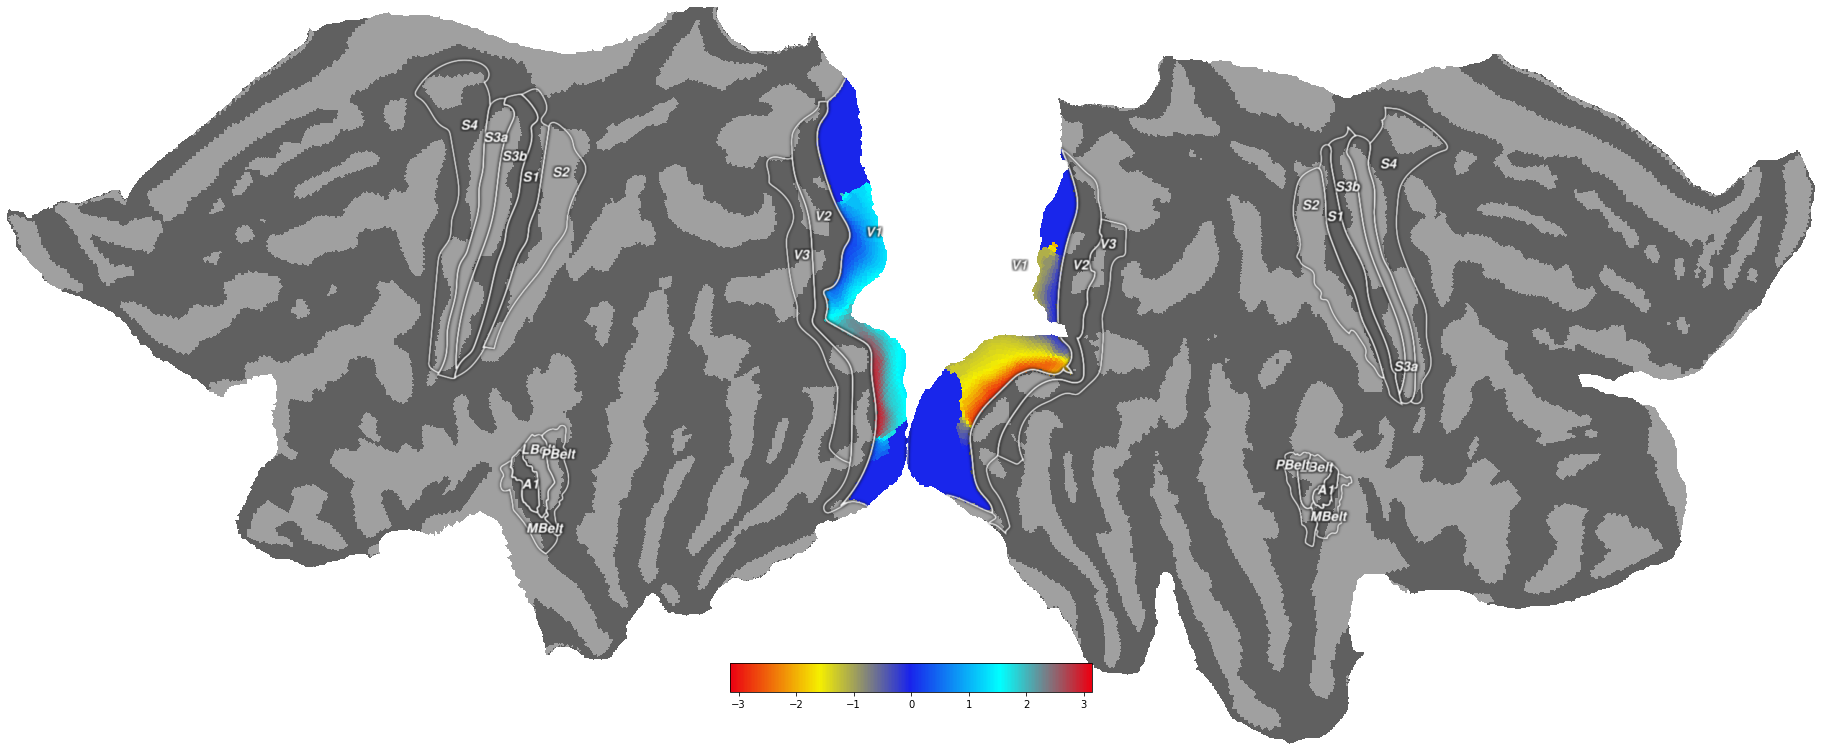

In [174]:
cx.quickshow(cx.Vertex(prfecc, subject='hcp_999999', cmap='Retinotopy_RYBCR', vmin = -np.pi, vmax=np.pi), with_curvature=True);


In [ ]:
roi_verts = cx.get_roi_verts('hcp_999999', 'V1',mask=True)

maskL=roi_verts['V1'][:59292]
maskR=roi_verts['V1'][59292:]

myv1surf=Subsurface('hcp_999999',[maskL,maskR]) # surf = fiducial, inflated, veryinflated, 
# hyperinflated, superinflated, flat, sphere

myv1surf.create()


# load prf paramaters for creating visual space distance matrix and limiting the vertices
prf_params = get_cortex(np.load(f'/scratch/2021/nprf_ss/derivatives/prf-fits/sub-0{sub}/dn-prf/sub-0{sub}_task-prf_space-fsLR_den-170k_desc-preproc_normPRF_params_cv_fold{fold}.npy'))
gfn_ecc = ecc(prf_params[:,0], prf_params[:,1])
gfn_rsq = prf_params[:,-1]

myv1surf.limit_vertices(gfn_ecc, gfn_rsq, ab.prf_ecc_threshold, ab.prf_rsq_threshold)
myv1surf.create_visual_space(prf_params[:,0], prf_params[:,1])

ab.prf_ecc_threshold
ab.prf_rsq_threshold

In [138]:
ab.prf_ecc_threshold
ab.prf_rsq_threshold

array([False, False, False, ..., False, False, False])

In [144]:
prfecc = np.zeros(get_cortex(data.T).mean(axis=1).shape)
prfecc[:] = np.nan
prfecc[boolmask] = angle(V1_params[:,0], V1_params[:,1])
prfecc[~V1_mask] = np.nan

(2939, 6)

In [166]:
V1_params_full.shape

(118584, 6)

In [164]:
V1_params = np.concatenate([np.array(what['prf_iterative_parameters']['v1_L']), np.array(what['prf_iterative_parameters']['v1_R'])])
V1_params_full = np.zeros([118584, 6])
V1_params_full[:] = np.nan
V1_params_full[boolmask] = V1_params
V1_params_full[~V1_mask] = np.nan

In [256]:
roi_verts = cx.get_roi_verts('hcp_999999', 'V1',mask=True)

maskL=roi_verts['V1'][:59292]
maskR=roi_verts['V1'][59292:]

myv1surf=Subsurface('hcp_999999',[maskL,maskR]) # surf = fiducial, inflated, veryinflated, 
# hyperinflated, superinflated, flat, sphere

myv1surf.create()

# load prf paramaters for creating visual space distance matrix and limiting the vertices
what = h5py.File(ab.prf_parameter_h5file, "r")
V1_params = np.concatenate([np.array(what['prf_iterative_parameters']['v1_L']), np.array(what['prf_iterative_parameters']['v1_R'])])
V1_params_full = np.zeros([118584, 6])
V1_params_full[:] = np.nan
V1_params_full[boolmask] = V1_params
V1_params_full[~V1_mask] = np.nan
gfn_ecc = ecc(V1_params_full[:,0], V1_params_full[:,1])
gfn_rsq = V1_params_full[:,-1]
# max_ecc_size = ab.prf_ecc_threshold
max_ecc_size = np.nanmax(gfn_ecc)
maxrsq = 0.2
# maxrsq = np.nanmax(gfn_rsq)

myv1surf.limit_vertices(gfn_ecc, gfn_rsq, max_ecc_size, maxrsq)
myv1surf.create_visual_space(V1_params_full[:,0], V1_params_full[:,1])

Generating subsurfaces
Creating distance by distance matrices


/tank/klundert/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:318: SparseEfficiencyWarning: splu requires CSC matrix format
  warn('splu requires CSC matrix format', SparseEfficiencyWarning)
/tank/klundert/downloads/prfpy/prfpy/utils.py:166: RuntimeWarning: invalid value encountered in less
  eccMask = ecc < maxecc
/tank/klundert/downloads/prfpy/prfpy/utils.py:167: RuntimeWarning: invalid value encountered in greater
  rsqMask = rsq > maxrsq
/tank/klundert/downloads/prfpy/prfpy/utils.py:222: RuntimeWarning: divide by zero encountered in true_divide
  CMF_matrix[CMF_matrix == np.inf] = np.nan
/tank/klundert/downloads/prfpy/prfpy/utils.py:222: RuntimeWarning: invalid value encountered in true_divide
  CMF_matrix[CMF_matrix == np.inf] = np.nan


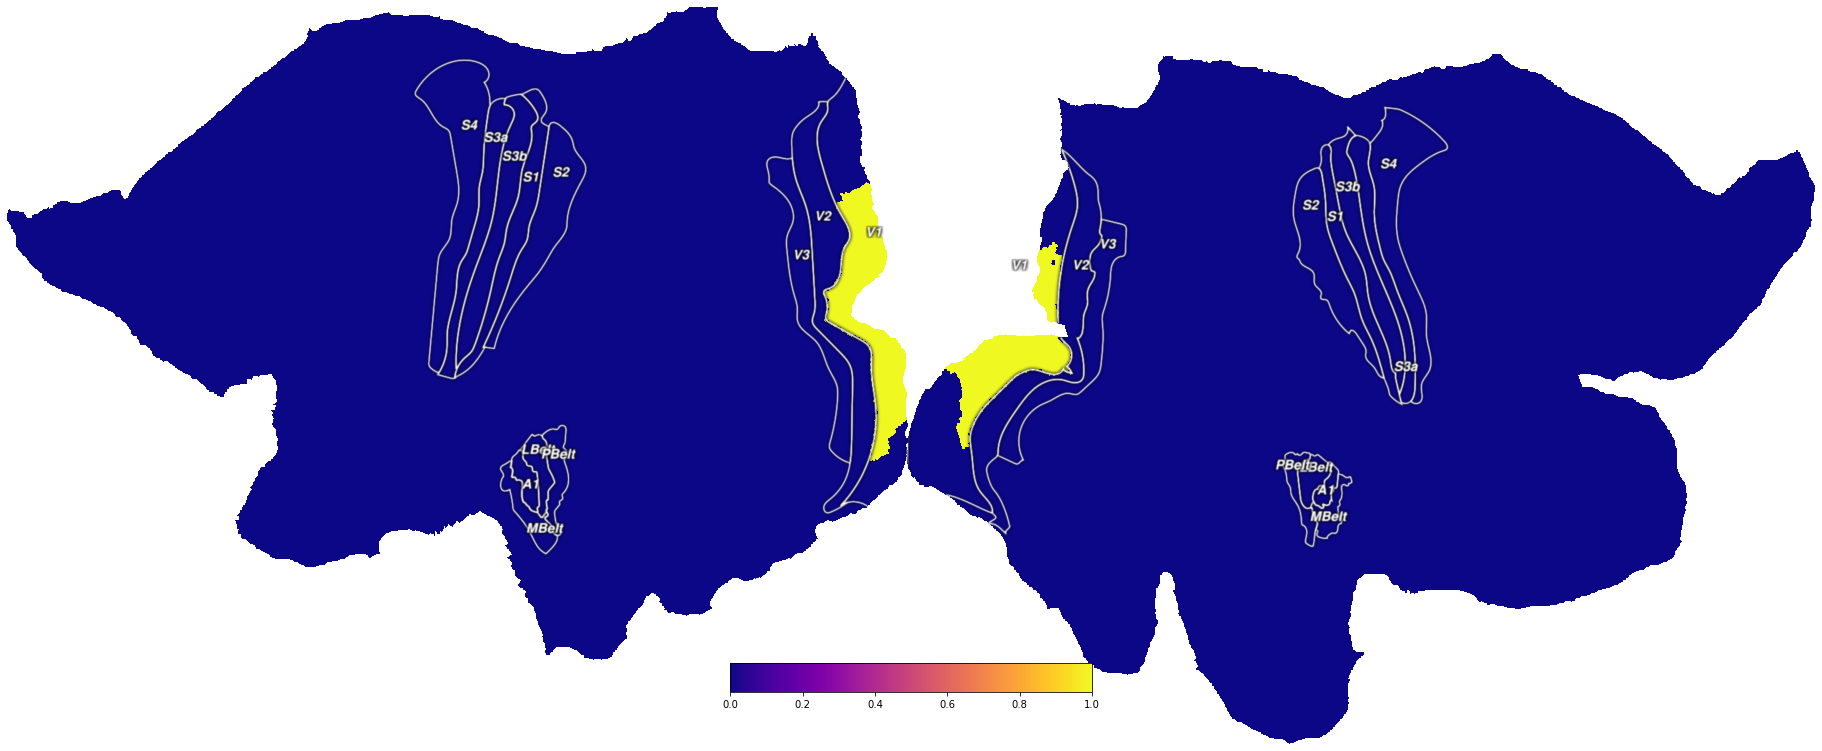

In [257]:
cx.quickshow(cx.Vertex(myv1surf.intmask, subject='hcp_999999', cmap='plasma'), with_curvature=True);


In [ ]:
train_stim=CFStimulus(mydat_train, myv1surf.subsurface_verts, myv1surf.logvisual_distance_matrix)
test_stim=CFStimulus(mydat_test, myv1surf.subsurface_verts, myv1surf.logvisual_distance_matrix)

In [ ]:
train_stim=CFStimulus(mydat_train, myv1surf.subsurface_verts, myv1surf.logvisual_distance_matrix)
test_stim=CFStimulus(mydat_test, myv1surf.subsurface_verts, myv1surf.logvisual_distance_matrix)

array([[ True, False, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False,  True]])

In [ ]:
sub = sys.argv[1]
ses = sys.argv[2]
n_jobs = int(sys.argv[3])
sl = int(sys.argv[4])
mask_type = sys.argv[5]
hrf_delay = float(sys.argv[7])
postFix = sys.argv[6]+'_hrf%.2f'%hrf_delay
k = int(sys.argv[8])

In [202]:
ac = AnalysisBase()
# ac.startup(subject='999999', experiment_id="ret", yaml_file="/tank/klundert/projects/hcp_movie/config.yml")

In [240]:
ab.full_data_subjects
ac.startup(subject='100610', experiment_id="ret", yaml_file="/tank/klundert/projects/hcp_movie/config.yml")
mydat_train_stim = get_cortex(ac._read_tc_data(run=0).T)
mydat_test_stim = get_cortex(ac._read_tc_data(run=1).T)
LO1mask = atlas_data_both_hemis == roi_index_dict['LO1']


Starting analysis of subject 100610 on romulus with settings 
{
 "identifier": "node230",
 "base_dir": "/scratch/2019/visual/hcp_{experiment}/",
 "code_dir": "/tank/tkn219/projects/hcp_movie/",
 "threads": 40
}
Getting whole-brain data from: /scratch/2019/visual/hcp_ret/subjects/100610/tfMRI_RETBAR1_*_Atlas_1.6mm_MSMAll_hp2000_clean.dtseries_sg_psc.nii
Getting whole-brain data from: /scratch/2019/visual/hcp_ret/subjects/100610/tfMRI_RETBAR2_*_Atlas_1.6mm_MSMAll_hp2000_clean.dtseries_sg_psc.nii


In [363]:
np.save(f'/tank/klundert/projects/cfdn/data/CF_fit_utils/subsurface_verts.npy', myv1surf.subsurface_verts)
np.save(f'/tank/klundert/projects/cfdn/data/CF_fit_utils/distance_matrix.npy', myv1surf.distance_matrix)
np.save(f'/tank/klundert/projects/cfdn/data/CF_fit_utils/logvisual_distance_matrix.npy', myv1surf.logvisual_distance_matrix)
np.save(f'/tank/klundert/projects/cfdn/data/CF_fit_utils/visual_distance_matrix.npy', myv1surf.visual_distance_matrix)

In [520]:
ac.prf_parameter_h5file

'/scratch/2019/visual/hcp_ret/999999/V12_retmap_results_polar_bar_iterative.h5'

In [418]:

chunkedtrain = [mydat_train_stim[i:i+61] for i in range(0,len(mydat_train_stim),61)]
chunkedtrain[0].shape

(61, 300)

In [241]:
train_stim=CFStimulus(mydat_train_stim, myv1surf.subsurface_verts, myv1surf.logvisual_distance_matrix)
test_stim=CFStimulus(mydat_test_stim, myv1surf.subsurface_verts, myv1surf.logvisual_distance_matrix)

mydat_train = mydat_train_stim[LO1mask]
mydat_test = mydat_test_stim[LO1mask]

model=CFGaussianModel(train_stim)

# Define sigmas
sigmas=np.array([0.5,1,2,3,4,5,7,10,20,30,40,60,80,110])

# Define the fitter
gf_vis = CFFitter(data=mydat_train,model=model)
gf_vis.n_jobs = 25
# Perform the fitting.
gf_vis.grid_fit(sigmas, verbose=True, n_batches=60)

Each batch contains approx. 4 voxels.


[Parallel(n_jobs=25)]: Using backend LokyBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done  60 out of  60 | elapsed:   23.2s finished


In [244]:
CF_bounds = [(0.1, 150),  # sigmas
                (0, 1000),  # beta
                (0, 0.0001), # baseline
                (0, 0)] # vert

CF_bounds = np.array(CF_bounds)
CF_bounds = np.repeat(CF_bounds[np.newaxis,...], gf_vis.gridsearch_params.shape[0], axis=0)
CF_bounds[:,3,0] = gf_vis.vertex_centres
CF_bounds[:,3,1] = gf_vis.vertex_centres

gf_vis.iterative_fit(rsq_threshold=-1, verbose=True, constraints=[], starting_params=gf_vis.gridsearch_params, bounds=CF_bounds, ftol=1e-7, xtol=1e-7)

# get model predictions
fit_stimulus = np.copy(gf_vis.model.stimulus)
gf_vis.model.stimulus = test_stim

sigmasi, betai, baselinei, vert_centrei, R2i = np.copy(gf_vis.iterative_search_params.T)
model_tc_vis = np.zeros(mydat_train.shape)
i = 0
for i in range(np.size(vert_centrei)):
    model_tc_vis[i,:] = gf_vis.model.return_prediction(sigmasi[i], betai[i], baselinei[i], gf_vis.vertex_centres[i])

gf_vis.model.stimulus = train_stim

# crossvalidate rsq
CV_rsq = np.nan_to_num(1-np.sum((mydat_test-model_tc_vis)**2, axis=-1)/(mydat_test.shape[-1]*mydat_test.var(-1)))
CV_rsq[CV_rsq <= -1] = np.nan
CV_rsq[CV_rsq >= 1] = np.nan

gf_vis.iterative_search_params[:,-1] = CV_rsq
gf_vis.iterative_search_params[:,3] = gf_vis.vertex_centres

# np.save(f'/scratch/2021/nprf_ss/derivatives/cf-fits/sub-0{sub}/limit_sample_gauss/visual_space/sub-0{sub}_task-prf_space-fsLR_den-170k_desc-preproc_gauss_CF_params_LOGvisual_space_fold{fold}_zsc.npy', gf_vis.iterative_search_params)



DNCF_bounds = [(0.1, 150),  # sigmas
            (0, 1000),  # prf amplitude
            (0, 0.0001), # baseline (A)
            (0, 0), # vert
            (0, 1000), # srf amplitude (C)
            (0.3, 180), # surround sigma 
            (0, 1000), # neural baseline (B)
            (1e-6, 1000)] # surround baseline (D)


DNCF_bounds = np.array(DNCF_bounds)
DNCF_bounds = np.repeat(DNCF_bounds[np.newaxis,...], gf_vis.gridsearch_params.shape[0], axis=0)
DNCF_bounds[:,3,0] = gf_vis.vertex_centres
DNCF_bounds[:,3,1] = gf_vis.vertex_centres

# set constraint for surround>centre sigma
constraints_gauss, constraints_css, constraints_dog, constraints_norm = [],[],[],[]
A_ssc_norm = np.array([[-1,0,0,0,0,1,0,0]])  
constraints_norm.append(LinearConstraint(A_ssc_norm,
                                            lb=0,
                                            ub=+np.inf))

gfdn = Norm_CFGaussianModel(train_stim)

fitdn = Norm_CFGaussianFitter(data=mydat_train,
                                   model=gfdn,
                                   n_jobs=25,
                                   previous_gaussian_fitter=gf_vis)

fitdn.iterative_fit(rsq_threshold=-1, verbose=True, constraints=constraints_norm, starting_params=gf_vis.iterative_search_params, bounds=DNCF_bounds, ftol=1e-7, xtol=1e-7)

sig, pamp, boldb, verti, srfamp, srfsig, neurb, surrb, Rsq = fitdn.iterative_search_params.T

fit_stimulus = np.copy(fitdn.model.stimulus)
fitdn.model.stimulus = test_stim

dncf_tc = np.zeros(mydat_test.shape)
i = 0
for i in range(np.size(vert_centrei)):
    dncf_tc[i,:] = fitdn.model.return_prediction(sig[i], pamp[i], boldb[i], gf_vis.vertex_centres[i], srfamp[i], srfsig[i], neurb[i], surrb[i])

fitdn.model.stimulus = train_stim

CVdncf_rsq = np.nan_to_num(1-np.sum((mydat_test-dncf_tc)**2, axis=-1)/(mydat_test.shape[-1]*mydat_test.var(-1)))

CVdncf_rsq[CVdncf_rsq <= -1] = np.nan
CVdncf_rsq[CVdncf_rsq >= 1] = np.nan

fitdn.iterative_search_params[:,-1] = CVdncf_rsq
fitdn.iterative_search_params[:,3] = gf_vis.vertex_centres

# np.save(f'/scratch/2021/nprf_ss/derivatives/cf-fits/sub-0{sub}/limit_sample_gauss/visual_space/sub-0{sub}_task-prf_space-fsLR_den-170k_desc-preproc_norm_CF_params_LOGvisual_space_fold{fold}_zsc.npy', fitdn.iterative_search_params)

[Parallel(n_jobs=25)]: Using backend LokyBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done 150 tasks      | elapsed:    8.5s
[Parallel(n_jobs=25)]: Done 207 out of 207 | elapsed:   26.6s finished
[Parallel(n_jobs=25)]: Using backend LokyBackend with 25 concurrent workers.
[Parallel(n_jobs=25)]: Done 150 tasks      | elapsed:  3.3min
[Parallel(n_jobs=25)]: Done 207 out of 207 | elapsed:  5.0min finished


In [500]:
toplot = np.zeros([118584,])
toplot[:] = np.nan
# datass = np.load('/tank/klundert/projects/cfdn/scripts/data_check_100610.npy')
toplot[boolmask] = 1

In [494]:
118584/12

# for slice_n, chunk in enumerate(chunkedmasks):

9882.0

In [511]:

# np.save(f'/tank/klundert/projects/cfdn/data/CF_fit_utils/visual_mask_hcp.npy', boolmask)
# boolmask
# 118584/61

# chunked_mask = [boolmask[i:i+9882] for i in range(0,len(boolmask),9882)]
for j, chunks in enumerate(chunked_mask):
    if chunks.sum()>0:
        print(j)
        print(f'voxels: {chunks.sum()}')

0
voxels: 175
2
voxels: 2719
3
voxels: 61
4
voxels: 3878
6
voxels: 191
8
voxels: 2612
9
voxels: 49
10
voxels: 3859


In [429]:
# for masks in [boolmask[i:i+61] for i in range(0,len(boolmask),61)]:
#     print(masks.sum())

In [379]:
sl = 1
sls = np.arange(sl*7,(sl+1)*7)
n_voxels = np.sum(boolmask[:,:,sls])

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

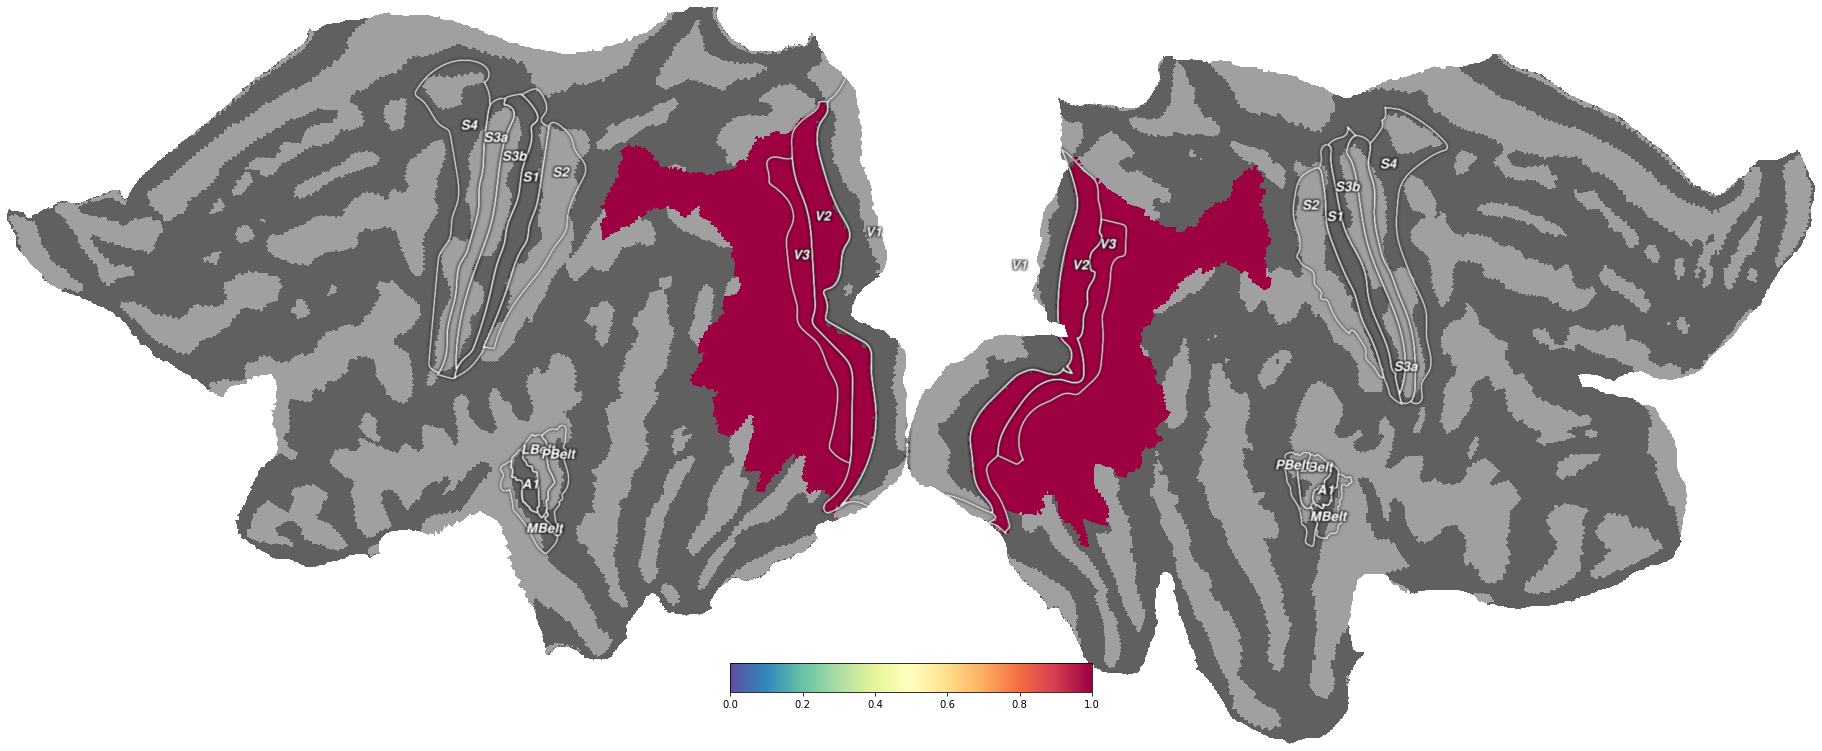

In [501]:
cx.quickshow(cx.Vertex(toplot, subject='hcp_999999', cmap='Spectral_r', vmin=0.00, vmax=1), with_curvature=True);


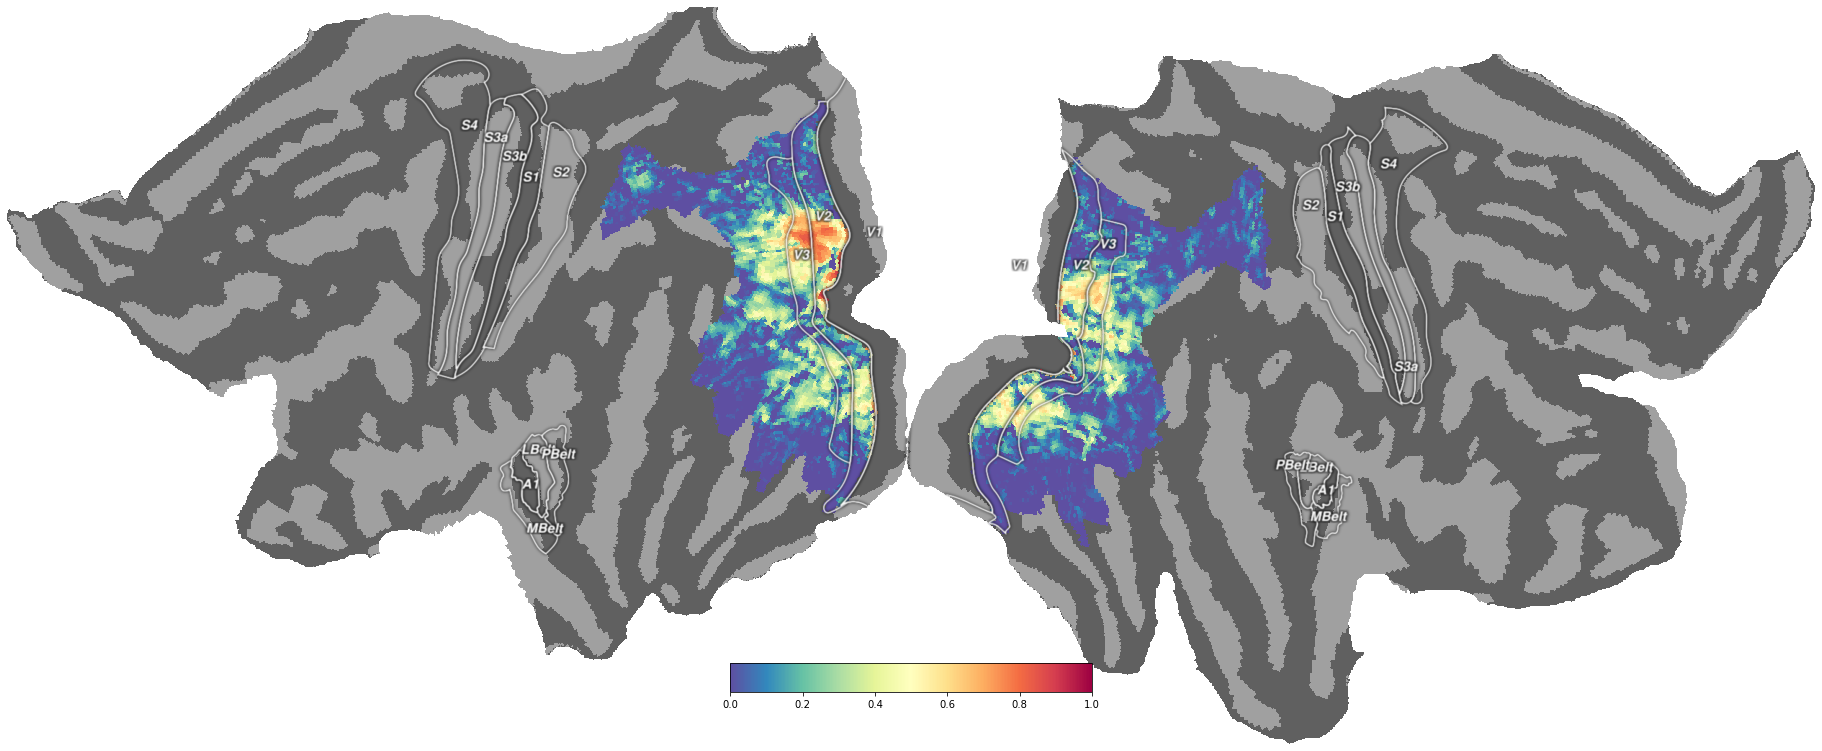

In [514]:
toplot = np.zeros([118584,])
toplot[:] = np.nan
# datass = np.load('/tank/klundert/projects/cfdn/scripts/data_check_100610.npy')
toplot[boolmask] = dattest[:,-1]
cx.quickshow(cx.Vertex(toplot, subject='hcp_999999', cmap='Spectral_r', vmin=0.00, vmax=1), with_curvature=True);

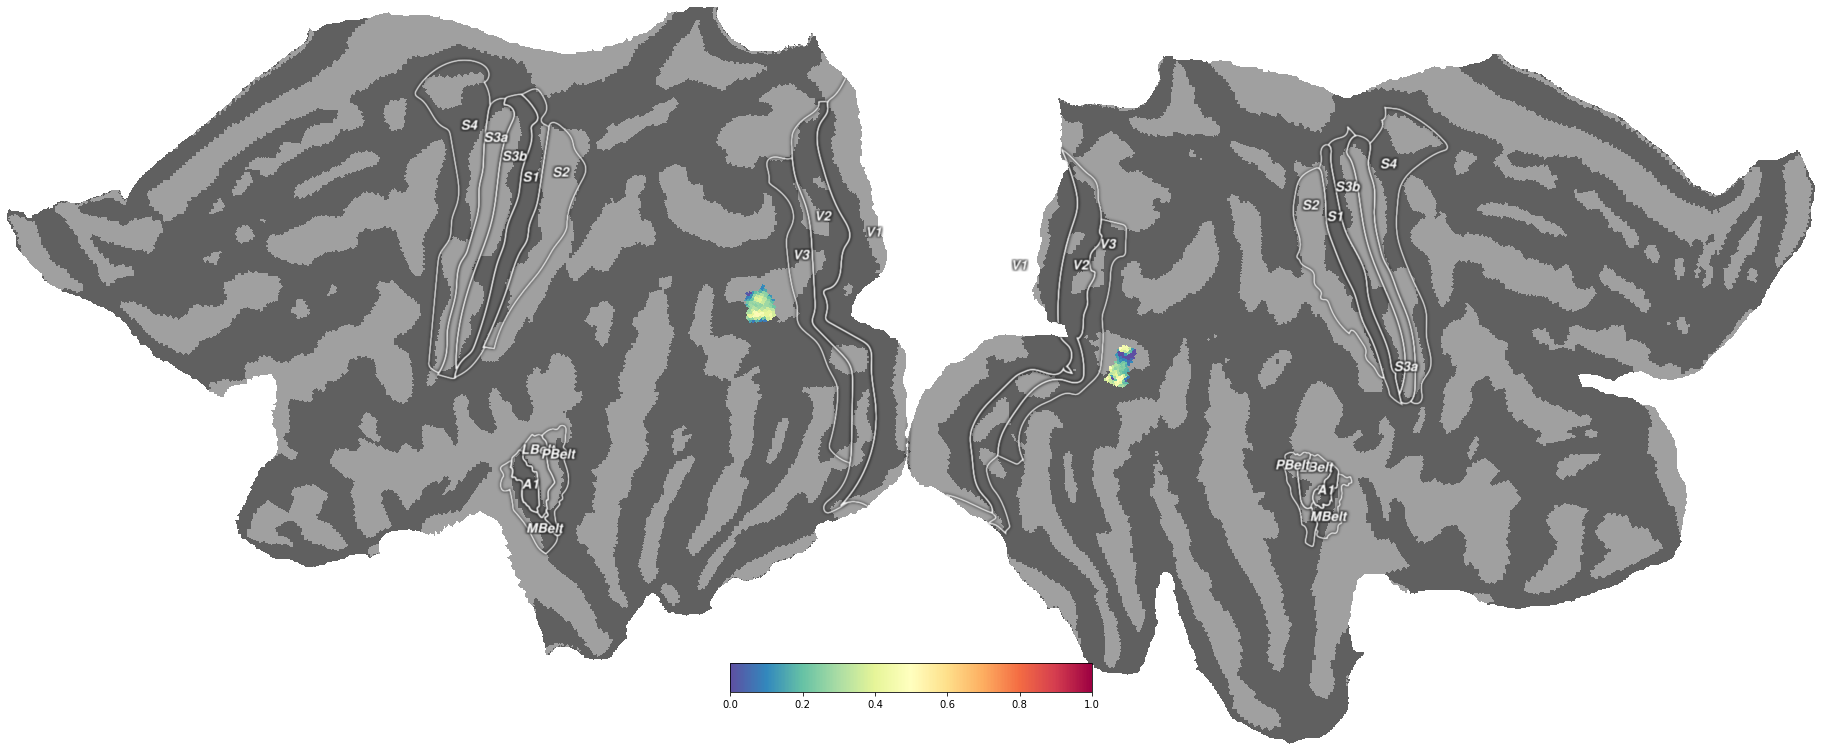

In [284]:
cx.quickshow(cx.Vertex(toplot, subject='hcp_999999', cmap='Spectral_r', vmin=0.00, vmax=1), with_curvature=True);


In [512]:
import glob
for j, infile in enumerate(sorted(glob.glob('/tank/klundert/projects/cfdn/scripts/*.npy'), key=os.path.getmtime)):
    if j == 0:
        dattest = np.load(infile)
    else:
        dattest = np.vstack([dattest, np.load(infile)])
    

In [ ]:
'tank/klundert/projects/cfdn/scripts/data_check_sub-100610_slice-446.npy

In [447]:
lol = np.vstack([np.load('/tank/klundert/projects/cfdn/scripts/data_check_sub-100610_slice-446.npy'), np.load('/tank/klundert/projects/cfdn/scripts/data_check_sub-100610_slice-447.npy')])

In [507]:
ROImask.sum()
boolmask.sum()

13544

In [497]:
import numpy as np
from IPython import embed as shell
import re
import os
import scipy.io as io
import nibabel as nb
import time
import sys
import h5py
from nilearn.surface import load_surf_data
sys.path.append('/tank/klundert/projects/cfdn/scripts/')





#################################
subs = [100610]
n_jobs = 23
ROImask = np.load(f'/scratch/2021/nprf_ss/derivatives/cf-fits/Surface_dm/visual_mask_hcp.npy')


# roi_index_dict = {
#     # somatosensory:
#     'CS1_4': 8, 'CS2_3a': 53, 'CS3_3b': 9, 'CS4_1': 51, 'CS5_2': 52,
#     # auditory:
#     'A1': 24, 'PBelt': 124, 'MBelt': 173, 'LBelt': 174, '52': 103, 'RI': 104,
#     # low-level visual:
#     'V1': 1, 'V2': 4, 'V3': 5,
#     # mid-level and high-level visual:
#     'V3A': 13, 'V3B': 19, 'IPS1': 17, 'LIPv': 48, 'LIPd': 95, 
#     'VIP': 49, 'FEF': 10, 'MST': 2, 'MT': 23, 'LO1': 20, 'LO2': 21, 'LO3': 159
#     }

# atlas_data = np.concatenate([load_surf_data(
#         os.path.join('/tank/klundert/content/data/atlas', f'Q1-Q6_RelatedParcellation210.CorticalAreas_dil_Colors.59k_fs_LR.dlabel.{hemi}.gii'))
#          for hemi in ['L', 'R']])
# atlas_data_both_hemis = np.mod(atlas_data, 180)


# ROImask = atlas_data_both_hemis == roi_index_dict[mask]


chunkedmasks = [ROImask[i:i+9882] for i in range(0,len(ROImask),9882)]

for sub in subs:
    chunk_n = 0
    for slice_n, chunk in enumerate(chunkedmasks):
        if chunk.sum() > 0:
            print(chunk_n)
            
        
#             jobscript = open('jobscript_base.sh')
#             working_string = jobscript.read()
#             jobscript.close()

#             RE_dict =  {
#             '---sub---': str(sub),
#             '---n_jobs---': str(n_jobs),
#             '---slice_n---': str(slice_n),
#             '---chunk_n---': str(chunk_n)}


#             for e in RE_dict:
#                 rS = re.compile(e)
#                 working_string = re.sub(rS, RE_dict[e], working_string)

#             of = open('jobscript', 'w')
#             of.write(working_string)
#             of.close()
#             print(working_string)
#             os.system(working_string)
            chunk_n = chunk_n + 1

0
1
2
3
4
5
6
7
8
9
10
11
